# Regression Coursework

## 1. Dataset Selection and UN SDG Alignment

### 1.1 Dataset Information

**Dataset Name:** Global Health, Nutrition, Mortality & Economic Data

**Source:** Kaggle

**Created by:** Miguel Roca

**Date Created/Published:** 2026

**Access Method:** Downloaded from Google Drive

### 1.2 UN Sustainable Development Goal Alignment

**Selected SDG:** SDG 3 - Good Health and Well-being

**Specific Target:** Life Expectancy

**Justification:**
This dataset directly supports SDG 3 by enabling:
- By knowing how country life expectancy is growing
- How other features are co-related to eachother
- How is expectancy decreasing



### Questions

This dataset can answer the following meaningful questions:

1. **Can we accurately predict life expectancy based on health metrics, economic indicators, and nutritional factors?**

2. **Which factors (mortality rates, GDP, nutrition, demographics) have the strongest impact on life expectancy?**


### 1.4 Dataset Features Description

The dataset contains 150 attributes covering health, demographic, economic, and nutritional indicators.

1. Life Expectancy
2. Infant Mortality Rate
3. Under 5 Mortality Rate
4. Neonatal Mortality Rate
5. Death Rate
6. Birth Rate
7. GDP per Capita
8. GNI per Capita
9. Income per Capita



# 1. **Exploratory Data Analysis and Data Understanding**

**Exploratory Data Analysis (EDA):**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFE



import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/lifeexpectancyDataset.csv')
df.head(5)

,Country,Year,Gender,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,...,Cereal Consumption Rye,Cereal Consumption Barley,Cereal Consumption Sorghum,Cereal Consumption Maize,Cereal Consumption Wheat,Cereal Consumption Rice,Diet Calories Animal Protein,Diet Calories Plant Protein,Diet Calories Fat,Diet Calories Carbohydrates
0,Afghanistan,1990,Both sexes,50.331,120.4,111.2,130.9,177.7,162.5,194.3,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
1,Afghanistan,1990,Female,51.442,114.2,105.1,124.7,173.1,158.0,189.7,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
2,Afghanistan,1990,Male,49.281,126.2,116.4,137.5,182.0,166.6,199.3,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
3,Afghanistan,1991,Both sexes,50.999,116.8,108.2,126.2,171.7,157.6,186.9,...,NaN,94.0,NaN,164.0,1043.0,159.0,64.96,173.68,370.08,1435.28
4,Afghanistan,1991,Female,52.119,110.7,102.1,120.4,167.1,153.0,182.6,...,NaN,94.0,NaN,164.0,1043.0,159.0,64.96,173.68,370.08,1435.28


In [ ]:
df.columns

Index(['Country', 'Year', 'Gender', 'Life Expectancy', 'Infant Mortality Rate',
       'Low CI Value Infant Mortality Rate',
       'High CI Value Infant Mortality Rate', 'Under 5 Mortality Rate',
       'Low CI Value Under 5 Mortality Rate',
       'High CI Value Under 5 Mortality Rate',
       ...
       'Cereal Consumption Rye', 'Cereal Consumption Barley',
       'Cereal Consumption Sorghum', 'Cereal Consumption Maize',
       'Cereal Consumption Wheat', 'Cereal Consumption Rice',
       'Diet Calories Animal Protein', 'Diet Calories Plant Protein',
       'Diet Calories Fat', 'Diet Calories Carbohydrates'],
      dtype='object', length=150)

In [ ]:
df.isnull().sum()

,0
Country,0
Year,0
Gender,0
Life Expectancy,0
Infant Mortality Rate,7593
...,...
Cereal Consumption Rice,9084
Diet Calories Animal Protein,9972
Diet Calories Plant Protein,9972
Diet Calories Fat,9972


In [ ]:
df.shape

(22050, 150)

In [ ]:
#cheking the missing percentage
df.isnull().sum() / len(df)
missing_percent = (df.isnull().sum() / len(df)) * 100

In [ ]:
#dropping the column whose percentage is less than 40
new_df = df.drop(columns=missing_percent[missing_percent > 40].index)



In [ ]:
#checking the shape now
new_df.shape



(22050, 29)

In [ ]:
#checking that our target column is there or not
new_df.columns

Index(['Country', 'Year', 'Gender', 'Life Expectancy', 'Infant Mortality Rate',
       'Low CI Value Infant Mortality Rate',
       'High CI Value Infant Mortality Rate', 'Under 5 Mortality Rate',
       'Low CI Value Under 5 Mortality Rate',
       'High CI Value Under 5 Mortality Rate', '% Population Aged 0-14',
       '% Population Aged 15-64', '% Population Aged 65+',
       'Neonatal Mortality Rate', 'Low CI Value Neonatal Mortality Rate',
       'High CI Value Neonatal Mortality Rate', 'Birth Rate', 'Death Rate',
       'GDP per Capita', 'Income per Capita', 'Total Population',
       'GNI per Capita', 'Conflict and Terrorism Deaths', 'Homicide Rate',
       'Vegetable Consumption', 'Fruit Consumption Other',
       'Fruit Consumption Oranges And Mandarines', 'Fruit Consumption Apples',
       'Fruit Consumption Grapes'],
      dtype='object')

In [ ]:
#now again dropping the columns which we dont want
new_df = new_df.drop(columns=['Country','Low CI Value Infant Mortality Rate', 'High CI Value Infant Mortality Rate', 'Low CI Value Under 5 Mortality Rate','High CI Value Under 5 Mortality Rate', 'Low CI Value Neonatal Mortality Rate', 'High CI Value Neonatal Mortality Rate'])

In [ ]:
#checking columns again
new_df.columns

Index(['Year', 'Gender', 'Life Expectancy', 'Infant Mortality Rate',
       'Under 5 Mortality Rate', '% Population Aged 0-14',
       '% Population Aged 15-64', '% Population Aged 65+',
       'Neonatal Mortality Rate', 'Birth Rate', 'Death Rate', 'GDP per Capita',
       'Income per Capita', 'Total Population', 'GNI per Capita',
       'Conflict and Terrorism Deaths', 'Homicide Rate',
       'Vegetable Consumption', 'Fruit Consumption Other',
       'Fruit Consumption Oranges And Mandarines', 'Fruit Consumption Apples',
       'Fruit Consumption Grapes'],
      dtype='object')

In [ ]:
#now checking the null values
new_df.isnull().sum()

,0
Year,0
Gender,0
Life Expectancy,0
Infant Mortality Rate,7593
Under 5 Mortality Rate,7593
% Population Aged 0-14,5364
% Population Aged 15-64,5364
% Population Aged 65+,5364
Neonatal Mortality Rate,5763
Birth Rate,5734


In [ ]:
new_df.dtypes

,0
Year,int64
Gender,object
Life Expectancy,float64
Infant Mortality Rate,float64
Under 5 Mortality Rate,float64
% Population Aged 0-14,float64
% Population Aged 15-64,float64
% Population Aged 65+,float64
Neonatal Mortality Rate,float64
Birth Rate,float64


In [ ]:
#now checking all the unique value
new_df['Gender'].unique()


array(['Both sexes', 'Female', 'Male'], dtype=object)

In [ ]:
#encoding gender into numeric
new_df = new_df.replace({'Gender': {'Male': 0, 'Female': 1, 'Both sexes': 2}})

In [ ]:
#filling the missing value
new_df = new_df.fillna(new_df.median())

In [ ]:
#now checking first 10 row is everything ok or not
new_df.head(10)


,Year,Gender,Life Expectancy,Infant Mortality Rate,Under 5 Mortality Rate,% Population Aged 0-14,% Population Aged 15-64,% Population Aged 65+,Neonatal Mortality Rate,Birth Rate,...,Income per Capita,Total Population,GNI per Capita,Conflict and Terrorism Deaths,Homicide Rate,Vegetable Consumption,Fruit Consumption Other,Fruit Consumption Oranges And Mandarines,Fruit Consumption Apples,Fruit Consumption Grapes
0,1990,2,50.331,120.4,177.7,48.308220,49.459238,2.232542,74.31,48.880,...,2530.174047,12412308.0,3210.0,1519.8538,12.791298,37.19,19.39,0.94,1.35,14.03
1,1990,1,51.442,114.2,173.1,48.034871,49.574715,2.390414,74.31,48.880,...,2530.174047,12412308.0,3210.0,1519.8538,12.791298,37.19,19.39,0.94,1.35,14.03
2,1990,0,49.281,126.2,182.0,48.569646,49.348779,2.081576,74.31,48.880,...,2530.174047,12412308.0,3210.0,1519.8538,12.791298,37.19,19.39,0.94,1.35,14.03
3,1991,2,50.999,116.8,171.7,48.217361,49.540308,2.242331,72.90,48.763,...,2530.174047,13299017.0,3210.0,3566.1731,14.666324,34.39,18.16,0.88,1.16,18.40
4,1991,1,52.119,110.7,167.1,47.977357,49.626537,2.396106,72.90,48.763,...,2530.174047,13299017.0,3210.0,3566.1731,14.666324,34.39,18.16,0.88,1.16,18.40
5,1991,0,49.938,122.5,176.0,48.445257,49.458439,2.096304,72.90,48.763,...,2530.174047,13299017.0,3210.0,3566.1731,14.666324,34.39,18.16,0.88,1.16,18.40
6,1992,2,51.641,113.3,165.9,48.130792,49.609846,2.259363,71.43,48.709,...,2530.174047,14485546.0,3210.0,4389.6738,13.721925,31.52,16.13,0.94,1.08,14.01
7,1992,1,52.774,107.3,161.4,47.928500,49.665390,2.406110,71.43,48.709,...,2530.174047,14485546.0,3210.0,4389.6738,13.721925,31.52,16.13,0.94,1.08,14.01
8,1992,0,50.570,118.9,170.2,48.321600,49.557478,2.120923,71.43,48.709,...,2530.174047,14485546.0,3210.0,4389.6738,13.721925,31.52,16.13,0.94,1.08,14.01
9,1993,2,52.256,109.9,160.4,48.088234,49.628356,2.283411,69.91,48.717,...,2530.174047,15816603.0,3210.0,4136.9678,13.326211,29.95,15.92,0.91,1.00,13.15


In [ ]:
#now exploring the data and calculating the mean, std of our target column
print(f"Mean of life expectancy : {new_df['Life Expectancy'].mean()}")
print(f"Standard deviation of life expectancy : {new_df['Life Expectancy'].std()}")
print(f"Max life expectancy : {new_df['Life Expectancy'].max()}")
print(f"Minimum life expectancy : {new_df['Life Expectancy'].min()}")


Mean of life expectancy : 69.01183008076735
Standard deviation of life expectancy : 9.691937627556895
Max life expectancy : 87.74700000000001
Minimum life expectancy : 24.834


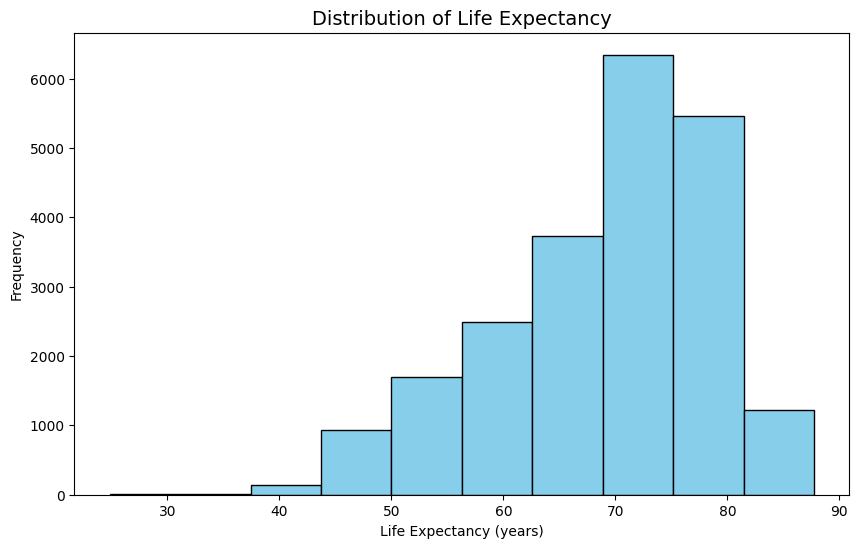

In [ ]:
#creating histogram for visualizing how data have been spread
plt.figure(figsize=(10, 6))
plt.hist(new_df['Life Expectancy'], color='skyblue', edgecolor='black')

#labels and title
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Frequency')
plt.title('Distribution of Life Expectancy', fontsize=14)


#Showing the plot
plt.show()

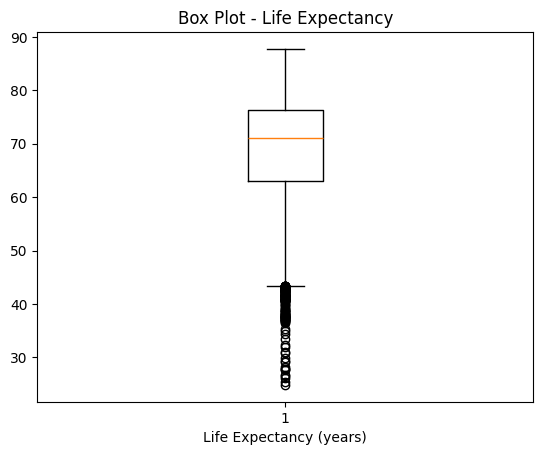

In [ ]:
#checking wheather there is outlier or not
plt.figure()
plt.boxplot(new_df['Life Expectancy'])
plt.title('Box Plot - Life Expectancy')
plt.xlabel('Life Expectancy (years)')
plt.show()

In [ ]:
#finding how much other features are co related to our target feature
correlations = new_df.corr()['Life Expectancy'].sort_values(ascending=False)
print(correlations)

#Wealthier countries and countries with more working age/elderly populations have higher life expectancy.
#Countries with high child mortality and high birth rates have LOWER life expectancy.

#so according to this we know our main feauture are Birth Rate, Mortality rates, Population age distribution, Economic indicators

Life Expectancy                             1.000000
% Population Aged 15-64                     0.681012
% Population Aged 65+                       0.566871
GNI per Capita                              0.455804
GDP per Capita                              0.448821
Income per Capita                           0.431431
Fruit Consumption Apples                    0.399736
Vegetable Consumption                       0.385503
Fruit Consumption Oranges And Mandarines    0.375698
Fruit Consumption Other                     0.302257
Year                                        0.260710
Fruit Consumption Grapes                    0.258841
Gender                                      0.151090
Total Population                           -0.009197
Conflict and Terrorism Deaths              -0.079946
Homicide Rate                              -0.132312
Death Rate                                 -0.594901
% Population Aged 0-14                     -0.731837
Under 5 Mortality Rate                     -0.

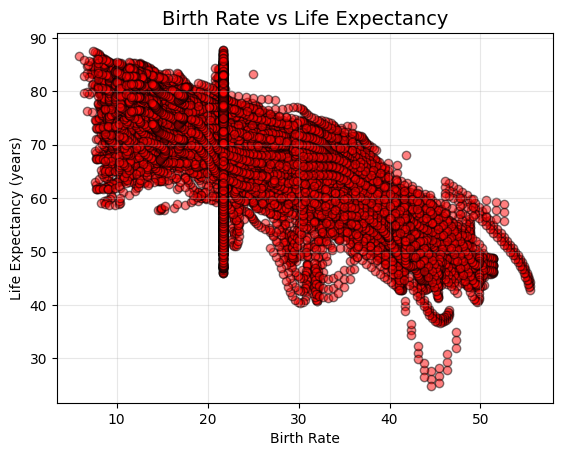

In [ ]:
#visualizing now strong related one

# Create scatter plot
plt.figure()
plt.scatter(new_df['Birth Rate'], new_df['Life Expectancy'],
            alpha=0.5, color='red', edgecolors='black')

# Add labels and title
plt.xlabel('Birth Rate')
plt.ylabel('Life Expectancy (years)')
plt.title('Birth Rate vs Life Expectancy', fontsize=14)

# Add grid
plt.grid(True, alpha=0.3)

# Show plot
plt.show()

#As Birth Rate increases Life Expectancy decreases

# **2. Build a Neural Network Model**

**Creating a nerual model**

In [ ]:
#now creating a model
X = new_df.drop('Life Expectancy', axis=1)
y = new_df['Life Expectancy']


#now splitting into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#neural network
neuralnetwork_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [ ]:
#training neural network
print("Training Neural Network...")
neuralnetwork_model.fit(X_train_scaled, y_train)

Training Neural Network...


MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [ ]:
#predecting neural network
y_train_pred_nn = neuralnetwork_model.predict(X_train_scaled)
y_test_pred_nn = neuralnetwork_model.predict(X_test_scaled)

In [ ]:
#calculating MSE, RMSE, R² of neural network
train_mse_nn = mean_squared_error(y_train, y_train_pred_nn)
train_rmse_nn = np.sqrt(train_mse_nn)
train_mae_nn = mean_absolute_error(y_train, y_train_pred_nn)
train_r2_nn = r2_score(y_train, y_train_pred_nn)

test_mse_nn = mean_squared_error(y_test, y_test_pred_nn)
test_rmse_nn = np.sqrt(test_mse_nn)
test_mae_nn = mean_absolute_error(y_test, y_test_pred_nn)
test_r2_nn = r2_score(y_test, y_test_pred_nn)


#Displaying results
print("nerual network performance")
print("\nTraining Set:")
print(f"MSE:{train_mse_nn:.4f}")
print(f"RMSE:{train_rmse_nn:.4f}")
print(f"MAE: {train_mae_nn:.4f}")
print(f"R2 Score:{train_r2_nn:.4f}")

print("\nTest Set:")
print(f"MSE:{test_mse_nn:.4f}")
print(f"RMSE:{test_rmse_nn:.4f}")
print(f"MAE: {test_mae_nn:.4f}")
print(f"R2 Score:{test_r2_nn:.4f}")


nerual network performance

Training Set:
MSE:5.7857
RMSE:2.4053
  MAE: 1.3643
R2 Score:0.9381

Test Set:
MSE:6.1312
RMSE:2.4761
  MAE: 1.4439
R2 Score:0.9361


# **3. Build Primary Machine Learning Models (Two Classical ML Models):**

**Linear Regression**

In [ ]:
#now creating the model
#creating the regularized Linear Regression
lr_model = Ridge()


In [ ]:
#training the model on training data
lr_model.fit(X_train, y_train)


Ridge()

In [ ]:
#predicting on training set
y_train_pred_lr = lr_model.predict(X_train)

#predicting on test set
y_test_pred_lr = lr_model.predict(X_test)

In [ ]:
#now checking now well did out model predicted calulating rmse, mse, mae, r^2 score

# Calculating for training set
train_mse_lr = mean_squared_error(y_train, y_train_pred_lr)
train_rmse_lr = np.sqrt(train_mse_lr)
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
train_r2_lr = r2_score(y_train, y_train_pred_lr)

# Calculating for test set
test_mse_lr = mean_squared_error(y_test, y_test_pred_lr)
test_rmse_lr = np.sqrt(test_mse_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

#displaying
print("Regularized linear regression performance")
print("\nTraining Set:")
print(f"MSE:{train_mse_lr:.4f}")
print(f"RMSE:{train_rmse_lr:.4f}")
print(f"MAE: {train_mae_lr:.4f}")
print(f"R² Score:{train_r2_lr:.4f}")
print("\nTest Set:")
print(f"MSE: {test_mse_lr:.4f}")
print(f"RMSE:{test_rmse_lr:.4f}")
print(f"MAE:{test_mae_lr:.4f}")
print(f"R² Score: {test_r2_lr:.4f}")



Regularized linear regression performance

Training Set:
MSE:16.8770
RMSE:4.1082
MAE: 2.7038
R² Score:0.8194

Test Set:
MSE: 16.6865
RMSE:4.0849
MAE:2.7455
R² Score: 0.8260


**Decision Tree**

In [ ]:
#now making model with decision tree
dt_model = DecisionTreeRegressor()


In [ ]:
#training the data
dt_model.fit(X_train, y_train)

DecisionTreeRegressor()

In [ ]:
#making predictions
#predicting on training set
y_train_pred_dt = dt_model.predict(X_train)

#predicting on test set
y_test_pred_dt = dt_model.predict(X_test)


In [ ]:
#now checking now well did out model predicted calulating rmse, mse, r^2 score

# Calculating for training set
train_mse_dt = mean_squared_error(y_train, y_train_pred_dt)
train_rmse_dt = np.sqrt(train_mse_dt)
train_mae_dt = mean_absolute_error(y_train, y_train_pred_dt)
train_r2_dt = r2_score(y_train, y_train_pred_dt)

# Calculating for test set
test_mse_dt = mean_squared_error(y_test, y_test_pred_dt)
test_rmse_dt = np.sqrt(test_mse_dt)
test_mae_dt = mean_absolute_error(y_test, y_test_pred_dt)
test_r2_dt = r2_score(y_test, y_test_pred_dt)

#displaying
print("Decision Tree performance")
print("\nTraining Set:")
print(f"MSE:{train_mse_dt:.4f}")
print(f"RMSE:{train_rmse_dt:.4f}")
print(f"MAE:{train_mae_dt:.4f}")
print(f"R² Score:{train_r2_dt:.4f}")
print("\nTest Set:")
print(f"MSE: {test_mse_dt:.4f}")
print(f"RMSE:{test_rmse_dt:.4f}")
print(f"MAE:{test_mae_dt:.4f}")
print(f"R² Score: {test_r2_dt:.4f}")

Decision Tree performance

Training Set:
MSE:4.1072
RMSE:2.0266
MAE:0.5297
R² Score:0.9560

Test Set:
MSE: 6.5996
RMSE:2.5690
MAE:1.2840
R² Score: 0.9312


# 4.**Hyperparameter Optimization with Cross-Validation :**

**Tunning hyper parameter with decision tree**

In [ ]:
#defining hyperparameter grid
dt_param_grid = {'max_depth': [5, 10, 15, 20]}


In [ ]:
# Create GridSearchCV
dt_grid_search = GridSearchCV(estimator=DecisionTreeRegressor(),param_grid=dt_param_grid, cv=3, scoring='r2')

In [ ]:
#fitting(tunning)
dt_grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [5, 10, 15, 20]}, scoring='r2')

In [ ]:
print(f"Best Parameters:{dt_grid_search.best_params_}")
print(f"Best CV R² Score:{dt_grid_search.best_score_:.2f}")

Best Parameters:{'max_depth': 20}
Best CV R² Score:0.92


**Hyper parameter tuning for Linear Regression**

In [ ]:
#defining hyperparameter
ridge_param_grid = {'alpha': [0.001, 0.01, 0.1, 1]}

ridge_grid_search = GridSearchCV(estimator=Ridge(),param_grid=ridge_param_grid, cv=3, scoring='r2')




In [ ]:
#fitting
ridge_grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1]}, scoring='r2')

In [ ]:
print(f"Best Parameters: {ridge_grid_search.best_params_}")
print(f"Best CV R² Score: {ridge_grid_search.best_score_:.2f}")

Best Parameters: {'alpha': 1}
Best CV R² Score: 0.82


# 5. **Feature Selection**

In [ ]:
#creating Ridge model with your best hyperparameter
ridge_model = Ridge(alpha=1)

In [ ]:
#applying recursive feature elimination to select top 10 features
rfe = RFE(estimator=ridge_model, n_features_to_select=10)
rfe.fit(X_train, y_train)

RFE(estimator=Ridge(alpha=1), n_features_to_select=10)

In [ ]:
#getting selected feature names
selected_features_ridge = X.columns[rfe.support_].tolist()

In [ ]:
print("selected feature of Ridge Regression:")
for i, feature in enumerate(selected_features_ridge, 1):
    print(f"{i}. {feature}")

selected feature of Ridge Regression:
1. Year
2. Gender
3. Infant Mortality Rate
4. Under 5 Mortality Rate
5. % Population Aged 0-14
6. % Population Aged 15-64
7. % Population Aged 65+
8. Death Rate
9. Fruit Consumption Oranges And Mandarines
10. Fruit Consumption Apples


**Why have we used RFE for linear Regression**

As Ridge is a Linear Model rfe works best with them as it evaluates features based on their linear contribution to predictions also rfe removes weakest features.


In [ ]:
#selecting fetaure for decision tree
# Get feature importances from your Decision Tree
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

In [ ]:
#selecting top 10 features
selected_features_dt = feature_importance.head(10)['Feature'].tolist()

print("selecting features by feature importance from decision tree:")
print(selected_features_dt)

selecting features by feature importance from decision tree:
['Birth Rate', 'Death Rate', 'GDP per Capita', 'Under 5 Mortality Rate', 'Gender', 'Fruit Consumption Oranges And Mandarines', '% Population Aged 65+', 'Fruit Consumption Apples', 'Homicide Rate', 'Total Population']


**Why have we used feature selection for Decision tree**

Decision Trees automatically calculate feature importance during training also it is easy to understand higher importance, feature used more in splits.

# **6. Final Models and Comparative Analysis**

**Final model of Regularized linear regression**

In [ ]:
#creating new datasets with ONLY selected features
X_train_ridge = X_train[selected_features_ridge]
X_test_ridge = X_test[selected_features_ridge]

In [ ]:
#training Ridge with optimal hyperparameter
final_ridge = Ridge(alpha=1)
final_ridge.fit(X_train_ridge, y_train)

Ridge(alpha=1)

In [ ]:
#predicting
y_train_pred_ridge = final_ridge.predict(X_train_ridge)
y_test_pred_ridge = final_ridge.predict(X_test_ridge)

In [ ]:
#now evaluating rmse, mse and r2 both training and testing data


train_mse_ridge = mean_squared_error(y_train, y_train_pred_ridge)
train_rmse_ridge = np.sqrt(train_mse_ridge)
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)


test_mse_ridge = mean_squared_error(y_test, y_test_pred_ridge)
test_rmse_ridge = np.sqrt(test_mse_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)


print("\nTraining Set Performance:")
print(f"MSE: {train_mse_ridge:.2f}")
print(f"RMSE: {train_rmse_ridge:.2f}")
print(f"R2 Score: {train_r2_ridge:.2f}")

print("\nTest Set Performance:")
print(f"MSE: {test_mse_ridge:.2f}")
print(f"RMSE: {test_rmse_ridge:.2f}")
print(f"R2 Score: {test_r2_ridge:.2f}")


Training Set Performance:
MSE: 17.34
RMSE: 4.16
R2 Score: 0.81

Test Set Performance:
MSE: 17.00
RMSE: 4.12
R2 Score: 0.82


**Final model of Decision Tree**

In [ ]:
#creating new datasets with ONLY selected features
X_train_dt = X_train[selected_features_dt]
X_test_dt = X_test[selected_features_dt]

In [ ]:
#training decision tree with optimal hyperparameters
final_dt = DecisionTreeRegressor(max_depth=20)
final_dt.fit(X_train_dt, y_train)

DecisionTreeRegressor(max_depth=20)

In [ ]:
#predicting
y_train_pred_dt = final_dt.predict(X_train_dt)
y_test_pred_dt = final_dt.predict(X_test_dt)

In [ ]:
#evaluating

train_mse_dt = mean_squared_error(y_train, y_train_pred_dt)
train_rmse_dt = np.sqrt(train_mse_dt)
train_r2_dt = r2_score(y_train, y_train_pred_dt)

test_mse_dt = mean_squared_error(y_test, y_test_pred_dt)
test_rmse_dt = np.sqrt(test_mse_dt)
test_r2_dt = r2_score(y_test, y_test_pred_dt)


print("\nTraining Set Performance:")
print(f"MSE: {train_mse_dt:.2f}")
print(f"RMSE: {train_rmse_dt:.2f}")
print(f"R2 Score: {train_r2_dt:.2f}")

print("\nTest Set Performance:")
print(f"MSE: {test_mse_dt:.2f}")
print(f"RMSE: {test_rmse_dt:.2f}")
print(f"R2 Score: {test_r2_dt:.2f}")


Training Set Performance:
MSE: 5.13
RMSE: 2.27
R2 Score: 0.95

Test Set Performance:
MSE: 7.93
RMSE: 2.82
R2 Score: 0.92


**Comparative Analysis**

In [ ]:
print("Comparison of Final Regression Models")

#For Ridge Regression
ridge_mse = mean_squared_error(y_test, y_test_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_mae = mean_absolute_error(y_test, y_test_pred_ridge)
ridge_r2 = r2_score(y_test, y_test_pred_ridge)
ridge_cv = 0.82

#This is for Decision Tree
dt_mse = mean_squared_error(y_test, y_test_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_mae = mean_absolute_error(y_test, y_test_pred_dt)
dt_r2 = r2_score(y_test, y_test_pred_dt)
dt_cv = 0.93



# Print simple table
print("\nRidge Regression:")
print("Features:", len(selected_features_ridge))
print("CV Score:", ridge_cv)
print("MSE:", round(ridge_mse, 4))
print("RMSE:", round(ridge_rmse, 4))
print("MAE:", round(ridge_mae, 4))
print("R2 Score:", round(ridge_r2, 4))

print("\nDecision Tree:")
print("Features:", len(selected_features_dt))
print("CV Score:", dt_cv)
print("MSE:", round(dt_mse, 4))
print("RMSE:", round(dt_rmse, 4))
print("MAE:", round(dt_mae, 4))
print("R2 Score:", round(dt_r2, 4))

#Which is the best model finding out
if ridge_r2 > dt_r2:
    print("\nBest Model: Ridge Regression")
else:
    print("\nBest Model: Decision Tree")

Comparison of Final Regression Models

Ridge Regression:
Features: 10
CV Score: 0.82
MSE: 17.0044
RMSE: 4.1236
MAE: 2.7589
R2 Score: 0.8227

Decision Tree:
Features: 10
CV Score: 0.93
MSE: 6.5996
RMSE: 2.569
MAE: 1.284
R2 Score: 0.9312

Best Model: Decision Tree
